# 선형 회귀 모델 훈련

**감사의 글**

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 강의노트이다. 보다 심화된 이해를 위해 책 원본을 읽을 것을 강력하게 권장한다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전한다.

**권장 사항**

[(강의노트) 모델 훈련](https://codingalzi.github.io/code-workout-ml/training_models/)를 병행하여 읽을 것을 권장한다.

## 환경설정

This project requires Python 3.10 or above:

In [2]:
import sys

assert sys.version_info >= (3, 10)

It also requires Scikit-Learn ≥ 1.6.1:

In [3]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

Let's define the default font sizes, to plot pretty figures:

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

**기본 라이브러리**

In [5]:
import numpy as np
import pandas as pd

## 선형 회귀 배치 학습 실험

**실험용 학습 데이터 생성 및 시각화**

배치 경사하강법 실험을 위한 훈련 데이터를 생성한다.
실제 관계는 

$$y = 4 + 3\, x_1 + \text{noise}$$

이며, 0에서 2 사이의 구간에서 200개의 샘플을 균등하게 무작위로 선택한다.
즉, $x_1 \sim U(0, 2)$이 성립한다.
$y$ 값에 추가된 노이즈 또한 0에서 1 사이의 구간에서 균등하게 무작위로 선택된다.

아래 코드는 데이터 생성과 생성된 데이터를 산점도를 그린다.

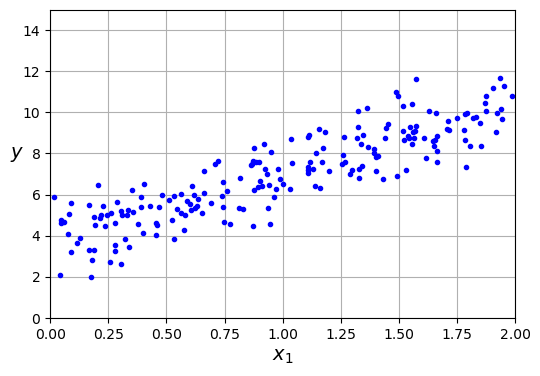

In [6]:
rng = np.random.default_rng(seed=42)  # 재현 가능한 난수 생성기 (시드 고정)
m = 200  # 훈련 샘플 수

# 입력 특성: [0, 2) 구간에서 균등 분포로 200개 샘플 생성 → (200, 1) 형태
X = 2 * rng.random((m, 1))

# 타깃값: y = 4 + 3*x1 + 가우시안 잡음 (평균 0, 표준편차 1)
y = 4 + 3 * X + rng.standard_normal((m, 1))

# 산점도 시각화
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")         # 파란 점으로 데이터 표시
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])     # x축 구간: [0, 2], y축 구간: [0, 15]
plt.grid()

plt.show()

**배치 경사하강법 시각화 함수 정의**

`plot_gradient_descent(theta, eta)` 함수를 정의한다. 
이 함수는 초기 파라미터 `theta`와 학습률 `eta`를 입력받아 1000 에포크 동안 배치 경사하강법을 실행한다. 
처음 20 에포크 동안 매 에포크마다 훈련된 선형 회귀 모델의 예측값을 직선으로 그려 
학습된 편향과 절편의 변화를 시각적으로 보여준다.

각 에포크에서의 비용 함수의 그래디언트는 아래 수식으로 계산되며, 
아래 코드에서 `gradients` 변수가 이를 가리킨다.

$$\nabla_\theta \text{MSE} = \frac{2}{m} X^T (X\theta - y)$$

In [7]:
import matplotlib as mpl
from sklearn.preprocessing import add_dummy_feature

# 훈련 데이터에 편향 항(x0 = 1) 추가 → (200, 2) 형태: [1, x1]
X_b = add_dummy_feature(X)

# 예측선 시각화를 위한 새로운 입력값: x1 = 0과 x1 = 2 두 점
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # 편향 항 추가 → [[1, 0], [1, 2]]

def plot_gradient_descent(theta, eta):
    """
    배치 경사하강법을 실행하고 수렴 과정을 시각화한다.
    - theta: 초기 파라미터 (편향 θ0, 기울기 θ1)
    - eta: 학습률
    """
    m = len(X_b)           # 훈련 샘플 수
    plt.plot(X, y, "b.")   # 훈련 데이터 산점도
    n_epochs = 1000        # 총 에포크 수
    n_shown = 20           # 처음 n_shown 에포크의 예측선만 시각화
    theta_path = []        # 에포크별 파라미터 저장 리스트

    for epoch in range(n_epochs):
        if epoch < n_shown:
            # 현재 theta로 예측선 계산 후 시각화 (에포크 순서에 따라 색상 변화)
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)

        # 배치 경사하강법: 전체 훈련 데이터로 그래디언트 계산
        # ∇MSE = (2/m) * X_b^T @ (X_b @ theta - y)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)

        # 파라미터 업데이트: θ ← θ - η * ∇MSE
        theta = theta - eta * gradients
        theta_path.append(theta)   # 업데이트된 파라미터 저장

    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")  # 서브플롯 제목에 학습률 표시
    return theta_path

**학습률에 따른 배치 경사하강법 수렴 비교**

세 가지 학습률($\eta$)로 배치 경사하강법을 실행하여 결과를 비교한다.

- $\eta = 0.02$ (너무 작음): 스텝 크기가 작아 수렴이 매우 느리고, 1000 에포크 안에 최적해에 도달하지 못할 수 있다.
- $\eta = 0.1$ (적절함): 빠르고 안정적으로 최적해에 수렴한다.
- $\eta = 0.5$ (너무 큼): 스텝이 지나치게 커서 최솟값을 건너뛰며 발산하거나 진동한다.

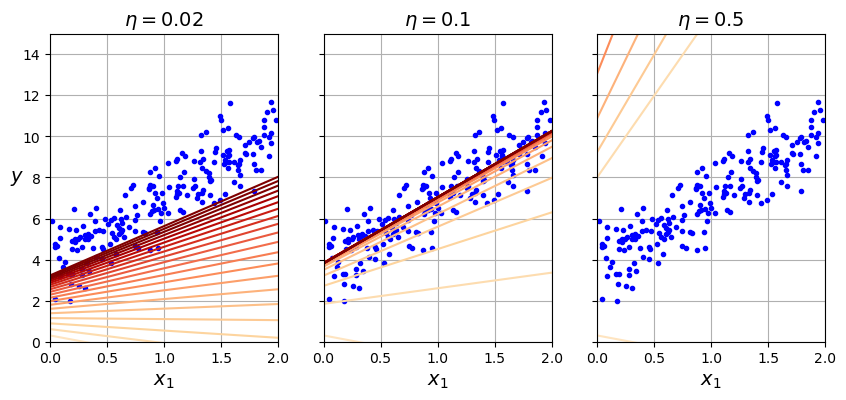

In [9]:
rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # 파라미터 무작위 초기화: [θ0(편향), θ1(기울기)]

plt.figure(figsize=(10, 4))

# 왼쪽 서브플롯: η = 0.02 (학습률 너무 작음 → 느린 수렴)
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)

# 가운데 서브플롯: η = 0.1 (적절한 학습률 → 빠르고 안정적인 수렴)
# theta_path_bgd에 에포크별 파라미터를 저장 (이후 확률적/미니배치 경사하강법 비교에 활용)
plt.subplot(132)
plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])  # y축 눈금 레이블 숨김

# 오른쪽 서브플롯: η = 0.5 (학습률 너무 큼 → 발산 또는 진동)
plt.subplot(133)
plot_gradient_descent(theta, eta=0.5)
plt.gca().axes.yaxis.set_ticklabels([])  # y축 눈금 레이블 숨김

plt.show()

## 로지스틱 회귀

### 붓꽃 이진 분류

붓꽃 데이터셋은 머신러닝 분류 모델을 소개할 때 자주 활용되는 유명한 데이터셋이다.
많은 서이트에서 다운로드 서비스를 제공하지만 여기서는 사이킷런 자체로 제공하는 데이터셋을 불러온다.

In [8]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

`load_iris()` 함수는 데이터셋을 사전 자료형과 유사한 `Bunch` 자료형으로 불러온다.
사용되는 키(key) 중에 `data` 키와 연결된 값이 4개의 특성으로 구성된 훈련셋 데이터프레임<font size='2'>DataFrame</font>이고
`target` 키와 연결된 값이 라벨셋 시리즈<font size='2'>Series</font>이다.

In [9]:
type(iris)

sklearn.utils._bunch.Bunch

포함된 키(key)는 다음과 같다.

In [10]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

- `DESCR` 키: 붓꽃 데이터셋에 대한 설명

In [11]:
print(iris.DESCR)  # iris['DESCR']

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

- `data` 키: 4 개의 특성으로 구성된 데이터프레임. 샘플은 총 150개.
    - `sepan length (cm)`: 꽃받침 길이
    - `sepan width (cm)`: 꽃받침 너비
    - `petal length (cm)`: 꽃잎 길이
    - `petal width (cm)`: 꽃잎 너비
- 처음 5개 데이터는 다음과 같음

In [12]:
iris.data.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


- `target` 키: 정수로 구성된 라벨셋. 1차원 어레이.

In [13]:
iris.target.head(5) # 세토사 품종 5개

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

품종의 실제 이름은 `target_names` 키의 값으로 지정되었으며 다음과 같이
`setosa`, `versicolor`, `virginica` 세 개의 품종이다.

In [14]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

**이진 분류: 버지니카 품종 감지기**

꽃잎의 길이와 너비 두 특성을 이용하여 붓꽃의 품종을 판별한다.
아래 코든는 로지스틱 회귀 모델을 이진 분류기로 훈련시킨다.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 두 특성만 사용하는 입력 데이터셋 준비
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 로지스틱 회귀 모델 준비: 
# `l1_ratio`는 L1과 L2 규제의 혼합 비율. 0이면 L2, 1이면 L1, 그 사이면 Elastic Net.
# `C`는 규제 강도. 기본값은 1. 작은 값일 수록 큰 규제.
log_reg = LogisticRegression(l1_ratio=0.0, 
                             C=2, 
                             random_state=42)

log_reg.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

**`predict()` vs `predict_proba()`**

`LogisticRegression`, `RandomForestClassifier`을 포함한 사이킷런의 대부분의 분류기는 
범주를 예측하는 `predict()`  메서드 이외에
범주별로 입력 샘플이 속할 확률을 계산하는 `predict_proba()` 메서드를 지원한다.
단, `SGDClassifer` 클래스는 기본적으로 확률 예측은 지원하지 않는다.

아래 코드는 테스트셋의 첫 5개 샘플에 대한 버지니카 품종 여부를 판별한다.
이진 분류기의 예측값은 양성 또는 음성이다.
따라서 테스트셋의 셋째 샘플만 버지니카 품종임을 알려준다.

In [16]:
log_reg.predict(X_test[:5])

array([False, False,  True, False, False])

반면에 아래 코드는 테스트셋의 첫 5개 샘플에 대한 범주별 확률을 계산한다.
어레이의 각 행은 샘플별로 음성일 확률과 양성일 확률을 포함한다.
테스트셋의 셋째 샘플의 경우에만 양성일 확률, 즉 버지니카 품종일 확률이 압도적으로 높다.

In [17]:
log_reg.predict_proba(X_test[:5])

array([[8.54331954e-01, 1.45668046e-01],
       [9.99998452e-01, 1.54794895e-06],
       [3.58237243e-04, 9.99641763e-01],
       [8.27775210e-01, 1.72224790e-01],
       [7.15555507e-01, 2.84444493e-01]])

## 소프트맥스 회귀

### 붓꽃 다중 클래스 분류

꽃잎의 길이와 너비 두 특성을 이용하여 세토사, 버시컬러, 버지니카 클래스 중 하나를 선택하는 모델을 훈련시킨다.

**소프트맥스 회귀 모델 훈련**

- `LogisticRegression` 모델을 다중 클래스 분류 모델로 훈련시키면 `multi_class='multinomial'` 옵션이
    자동 지정되어 소프트맥스 회귀를 적용함
- `C=30`: 약한 규제

In [18]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",30
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

아래 코드는 테스트셋의 첫 5개 샘플의 품종을 판별한다.

In [19]:
softmax_reg.predict(X_test[:5])

array([1, 0, 2, 1, 1])

반면에 아래 코드는 테스트셋의 첫 5개 샘플에 대한 범주별 확률을 계산한다.

In [20]:
softmax_reg.predict_proba(X_test[:5])

array([[5.79887294e-06, 9.82825932e-01, 1.71682688e-02],
       [9.92803024e-01, 7.19697591e-03, 2.46611952e-13],
       [1.85130240e-17, 9.37494824e-07, 9.99999063e-01],
       [1.50163356e-05, 9.39662109e-01, 6.03228752e-02],
       [2.81177214e-06, 8.94089601e-01, 1.05907587e-01]])

## 연습 문제

### 문제 1. 소프트맥스 회귀 모델의 배치 경사하강법 적용 훈련 구현

(1) 붓꽃 데이터셋을 대상으로 다중 클래스 분류를 진행하는 소프트맥스 회귀 모델에
사용되는 배치 경상하강법을 직접 구현하라.
단, 사이킷런은 전혀 사용하지 않고 넘파이 라이브러리만 이용해야 한다.

**넘파이 불러오기**

In [21]:
import numpy as np

In [22]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

**붓꽃 데이터셋 적재**

In [23]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

붗꽃 특성 데이터프레임

In [24]:
iris.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


붗꽃 타깃 특성 시리즈

| 번호 | 품종 |
| :---: | :---: |
| 0 | Setosa |
| 1 | Versicolor |
| 2 | Verginica |

In [25]:
iris.target

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

훈련셋과 타깃셋을 지정한다.
훈련셋 샘플은 꽃잎의 길이와 너비 2개 특성만 사용한다.
또한 데이터프레임을 넘파이 어레이로 변환한다.

In [26]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"].values

**입력 데이터셋 변환: 항목 1 추가**

모든 훈련 샘플에 1을 첫째 특성으로 추가한다.
이유는 예측값을 계산할 때 다음과 같이 편향(bias)를 고려해서 계산이 사용되기 때문이다.

$$
1\cdot \theta_0 + x_1 \cdot \theta_1 + x_2 \cdot \theta_{2}
= [1, x_1, x_2]\,
\begin{bmatrix}
\theta_0\\
\theta_1 \\
\theta_2
\end{bmatrix}
$$

사이킷런의 `add_dummy_feature()` 함수를 이용하면 되지만 여기서는 경사하강법을 보다 깊이 이해하기 위해 직접 구현한다.

- `np_c[]`: 어레이를 좌우로 이어붙이기
- `np.ones()`: 1로 구성된 어레이 생성. 인자는 생성되는 어레이 모양(shape)

In [27]:
X_with_bias = np.c_[np.ones(len(X)), X]

변환된 입력 데이터셋은 다음과 같다.

In [28]:
X_with_bias[:5]

array([[1. , 1.4, 0.2],
       [1. , 1.4, 0.2],
       [1. , 1.3, 0.2],
       [1. , 1.5, 0.2],
       [1. , 1.4, 0.2]])

반면에 기존의 입력 데이터셋 `X`는 다음과 같다.

In [29]:
X[:5]

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

**훈련셋, 검증셋, 테스트셋 구분**

사이킷런의 `train_test_split()` 함수를 이용하면 간단하지만 역시나 직접 구현한다.

- 훈련셋, 검증셋, 테스트셋 비율은 6:2:2

In [30]:
test_ratio = 0.2              # 테스트셋 비율
validation_ratio = 0.2        # 검증셋 비율

total_size = len(X_with_bias) # 150. 전체 입력 데이터셋 크기

test_size = int(total_size * test_ratio)              # 테스트셋 크기
validation_size = int(total_size * validation_ratio)  # 검증셋 크기
train_size = total_size - test_size - validation_size # 훈련셋 크기

3개의 데이터셋으로 분류하기 전에 전체 입력 데이터셋을 무작위로 섞어야 한다.
하지만 여기서는 0부터 149의 행 인덱스를 무작위로 섞에 데이터셋을 분리한다.

- 0부터 149의 인덱스를 무작위로 섞기

In [31]:
np.random.seed(42)
rnd_indices = np.random.permutation(total_size)

인덱스 순서가 섞였다.

In [32]:
rnd_indices

array([ 73,  18, 118,  78,  76,  31,  64, 141,  68,  82, 110,  12,  36,
         9,  19,  56, 104,  69,  55, 132,  29, 127,  26, 128, 131, 145,
       108, 143,  45,  30,  22,  15,  65,  11,  42, 146,  51,  27,   4,
        32, 142,  85,  86,  16,  10,  81, 133, 137,  75, 109,  96, 105,
        66,   0, 122,  67,  28,  40,  44,  60, 123,  24,  25,  23,  94,
        39,  95, 117,  47,  97, 113,  33, 138, 101,  62,  84, 148,  53,
         5,  93, 111,  49,  35,  80,  77,  34, 114,   7,  43,  70,  98,
       120,  83, 134, 135,  89,   8,  13, 119, 125,   3,  17,  38,  72,
       136,   6, 112, 100,   2,  63,  54, 126,  50, 115,  46, 139,  61,
       147,  79,  59,  91,  41,  58,  90,  48,  88, 107, 124,  21,  57,
       144, 129,  37, 140,   1,  52, 130, 103,  99, 116,  87,  74, 121,
       149,  20,  71, 106,  14,  92, 102], dtype=int32)

무작위로 섞인 인덱스를 이용하여 지정된 비율로 훈련셋, 검증셋, 테스트셋으로 분리한다.

In [33]:
# 훈련셋
X_train = X_with_bias[rnd_indices[:train_size]]
y_train = y[rnd_indices[:train_size]]

# 검증셋
X_valid = X_with_bias[rnd_indices[train_size:-test_size]]
y_valid = y[rnd_indices[train_size:-test_size]]

# 테스트셋
X_test = X_with_bias[rnd_indices[-test_size:]]
y_test = y[rnd_indices[-test_size:]]

**타깃 원-핫 인코딩**

라벨은 0, 1, 2의 정수로 지정되어 있다.
그런데 다중 클래스 분류기는
각 샘플에 대해 주어진 세 개의 범주(품성)에 속할 확률로 구성된 길이가 3인 1차원 어레이를 계산한다.
예를 들어 세토사 품종이라고 예측되는 샘플에 대한 확률 예측값은 아래처럼
0번 인덱스의 값이 압도적으로 1에 가깝게 나와야 한다.

```
[0.9, 0.01, 0.09]
```

즉, 0번 인덱스의 값이 가장 크고, 나머지는 거의 0에 가깝게 계산돼야 한다.

따라서 확률 예측값과 타깃(라벨) 사이의 오차를 이용하여 비용함수를 계산하려면
라벨을 원-핫 인코딩해서 모양을 맞춰야 하며,
이를 위해 원-핫 인코딩 기법을 활용한다.

아래 `to_one_hot()` 함수가 원-핫 인코딩을 실행한다.

- `np.diag(np.ones(n))`: 대각선상은 1, 나머지 항목은 0으로 채워진 (n, n) 모양의 2차원 어레이 생성. 즉, 단위 행렬 생성.
- `n`은 타깃 클래스의 개수. 예를 들어 붓꽃 데이터셋의 경우는 3을 가리킴.
- 생성된 단위 행렬에 타깃 클래스들로 이뤄진 정수 리스트를 이용하여 팬시 인덱싱을 진행하면 원-핫 인코딩된 어레이가 생성됨.
- 팬시 인덱싱; `a[[1, 3, 2, 3, 2, 2, 1]]`는 `a[1]`, `a[3]`, `a[2]`, `a[3]`, `a[2]`, `a[2]`, `a[1]` 로 구성된 어레이 생성.

In [34]:
def to_one_hot(y):
    """
    y는 타깃 정숫값으로 구성된 1차원 어레이
    """
    n = y.max() + 1           # y 항목의 최대값 + 1. 즉, 라벨 종류 개수
    a = np.diag(np.ones(n))   # (n, n) 모양의 단위 행렬
    return a[y]               # 팬시 인덱싱

처음 10개의 라벨에 대해 원-핫 인코딩을 실행하면 다음과 같다.

- 처음 10개의 라벨

In [35]:
y_train[:10]

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

- 원-핫 인코딩된 처음 10개의 라벨

In [36]:
to_one_hot(y_train[:10])

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

잘 작동한다.
이제 모든 라벨을 원-핫 인코딩한다.

In [37]:
Y_train_one_hot = to_one_hot(y_train) # 훈련셋 라벨 원-핫 인코딩
Y_valid_one_hot = to_one_hot(y_valid) # 검증셋 라벨 원-핫 인코딩
Y_test_one_hot = to_one_hot(y_test)   # 테스트셋 라벨 원-핫 인코딩

예를 들어 변환된 훈련셋에 포함된 90개의 라벨은 3개의 특성을 갖는다.

- 훈련셋 크기는 90. 전체 데이터셋 크기인 150의 60%.

In [38]:
Y_train_one_hot.shape

(90, 3)

- 검증셋과 테스트셋의 크기는 30.

In [39]:
Y_valid_one_hot.shape

(30, 3)

In [40]:
Y_test_one_hot.shape

(30, 3)

**특성 표준화**

편향값 1을 제외한 모든 특성에 대해 표준화를 진행한다.
이때 사용되는 평균값(mean)과 표준편차(std)는 훈련셋의 평균값과 표준편차며,
이를 이용하여 훈련셋, 검증셋, 테스트셋의 표준화를 함께 진행한다.
즉, 검증셋과 테스트셋의 평균값과 표준편차는 전혀 이용하지 않는다.

In [41]:
# 훈련셋의 평균값과 표준편차(편향값 제외). 특성별 계산.
mean = X_train[:, 1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)

# 표준화 진행. 편향값 제외.
X_train[:, 1:] = (X_train[:, 1:] - mean) / std
X_valid[:, 1:] = (X_valid[:, 1:] - mean) / std
X_test[:, 1:] = (X_test[:, 1:] - mean) / std

**소프트맥스 점수**

주어진 붓꽃 샘플이 특정 품종 $k$에 속할 확률을 계산하기 위해 먼저 소프트맥스 점수를 계산한다.

입력 샘플 $\mathbf x = [x_1, x_2]$가 주어졌을 때 각각의 품종 클래스 $k$ 에 대해 **소프트맥스 점수** $s_k(\mathbf x)$는
다음과 같이 선형 회귀 방식으로 계산한다.

$$
\begin{align*}
s_k(\mathbf{x}) & = \theta_0^{(k)} + \theta_1^{(k)} x_1 + \theta_2^{(k)} x_n\\[1ex]
& = [1, x_1, x_2]\,
\begin{bmatrix}
\theta_0^{(k)}\\
\theta_1^{(k)} \\
\theta_2^{(k)}
\end{bmatrix}
\end{align*}
$$    

위 식에서 $\theta_i^{(k)}$ 는 $i$ 번째 특성에 대한 파라미터이며, $k$ 품종과 관련된 소프트맥스 점수 계산에 사용된다.
따라서 총 3 $\times$ 3 = 9개의 파라미터가 모델 훈련을 통해 학습된다.
9 개의 파라미터로 구성된 파라미터 행렬은 아래와 같다.

$$
\Theta =
\begin{bmatrix}
\theta_0^{(0)} & \theta_0^{(1)} & \theta_0^{(2)} \\
\theta_1^{(0)} & \theta_1^{(1)} & \theta_1^{(2)} \\
\theta_2^{(0)} & \theta_2^{(1)} & \theta_2^{(2)}
\end{bmatrix}
$$

반면에 꽃잎 길이와 너비 두 개의 특성과 추가된 편향으로 구성된 훈련셋 `X_train`은 다음과 같은 형식이다.
각 행이 하나의 샘플을 가리키며, 여기서는 훈련셋에 90개의 샘플이 포함되어 있는 것을 표현한다.

$$
\mathbf{X}_{train} =
\begin{bmatrix}
1 & x_1^{(0)} & x_2^{(0)} \\
1 & x_1^{(1)} & x_2^{(1)} \\
 & \vdots & \\
1 & x_1^{(89)} & x_2^{(89)}
\end{bmatrix}
$$

모든 훈련 샘플에 대한 소프트맥스 점수를 다음과 같이 행렬곱으로 일시에 계산할 수 있다.

$$
s(\mathbf{X}_{train})
= \mathbf{X}_{train} \,\, \Theta 
= \begin{bmatrix}
1 & x_1^{(0)} & x_2^{(0)} \\
1 & x_1^{(1)} & x_2^{(1)} \\
 & \vdots & \\
1 & x_1^{(89)} & x_2^{(89)}
\end{bmatrix}
\,\,
\begin{bmatrix}
\theta_0^{(0)} & \theta_0^{(1)} & \theta_0^{(2)} \\
\theta_1^{(0)} & \theta_1^{(1)} & \theta_1^{(2)} \\
\theta_2^{(0)} & \theta_2^{(1)} & \theta_2^{(2)}
\end{bmatrix}
= \begin{bmatrix}
s_0(\mathbf{x}^{(0)}) & s_1(\mathbf{x}^{(0)}) & s_2(\mathbf{x}^{(0)}) \\
s_0(\mathbf{x}^{(1)}) & s_1(\mathbf{x}^{(1)}) & s_2(\mathbf{x}^{(1)}) \\
& \vdots & \\
s_0(\mathbf{x}^{(89)}) & s_1(\mathbf{x}^{(89)}) & s_2(\mathbf{x}^{(89)})
\end{bmatrix}
$$

**소프트맥스 함수**

주어진 샘플이 $k$ 품종에 속할 확률 $\hat p_k$를 **소프트맥스 함수** $\sigma()$가 다음과 같이 계산한다.
인자는 소프트맥스 점수로 구성된 벡터 $\mathbf{s}(\mathbf{x}) = [s_0(\mathbf{x}), s_1(\mathbf{x}), s_{2}(\mathbf{x})]$ 이다.

$$
\hat p_k
= \sigma(\mathbf{s}(\mathbf{x}))[k]
= \frac{\exp(s_k(\mathbf x))}{\sum\limits_{j=0}^{2}\exp(s_j(\mathbf x))}
$$

즉, 다음이 성립한다.

$$
\sigma(\mathbf{s}(\mathbf{x})) = [\hat p_0, \hat p_1, \hat p_{2}]
$$

소프트맥스 회귀 모델의 각 샘플에 대한 최종 예측 라벨은 추정 확률이 가장 높은 품종으로 선택된다.

$$
\hat y
= \mathrm{np.argmax}(\sigma(\mathbf{s}(\mathbf{x})))
= \mathrm{np.argmax}([\hat p_0, \hat p_1, \hat p_{2}])
$$

위 설명을 종합해서 모든 샘플에 대한 확률 예측값을 동시에 실행하는 행렬 연산을 다음과 같이
정의할 수 있다.

$$
\sigma(\mathbf{s}(\mathbf{X}_{train})) = \sigma(\mathbf{X}_{train} \, \Theta)
$$

아래 `softmax()` 함수는 소프트맥스 함수 $\sigma()$를 구현하며,
`(m, K)` 모양의 훈련셋에 대해 행별로, 즉 샘플별로 작동한다.

In [42]:
def softmax(logits):
    """
    - logits: 모든 샘플에 대한 소프트맥스 점수로 구성된 (m, K) 모양의 어레이.
    - m은 샘플 수.
    - K는 라벨 종류 수.
    - 반환값은 s(X)
    """

    exps = np.exp(logits)                      # 확률 예측값 ^p_k 계산에 사용된 분자
    exp_sums = exps.sum(axis=1, keepdims=True) # 확률 예측값 ^p_k 계산에 사용된 분모. 샘플별 계산.
    return exps / exp_sums

**모델 예측값**

각 샘플별 최종 예측 라벨은 확률값이 가장 큰 값의 인덱스로 지정된다.

$$
\hat{\mathbf{y}} = \mathrm{np.argmax}(\sigma(\mathbf{X}_{train} \, \Theta), \mathrm{axis}=1)
$$

**비용 함수**

붓꽃 데이터셋을 다중 클래스 분류하는
소프트맥스 회귀의 훈련에 사용되는 **배치 경사하강법** 적용 과정을 구현하려면
비용 함수와 비용 함수의 그레이디언트 벡터를 다뤄야 한다.
여기서는 먼저 규제를 전혀 사용하지 않는 경사하강법을 구현한다.

**크로스 엔트로피<font size='2'>cross entropy</font> 비용 함수**

$k$-범주 각각에 대한 적절한 가중치들의 벡터 $\mathbf{\theta}^{(k)} = [\theta_0^{(k)}, \theta_1^{(k)}, \dots, \theta_n^{(k)}]$를 
경사하강법을 이용하여 업데이트 한다.
이를 위해 예측 라벨이 아닌 범부별 예측 확률값에 근거한 **크로스 엔트로피**<font size='2'>cross entropy</font>를 비용 함수로 사용한다.

- $y^{(i)}_k$: $i$-번째 샘플에 대한 원-핫 인코딩된 타깃(라벨).
- $\hat{p}_k^{(i)}$: $i$-번째 샘플이 $k$ 범주에 속할 확률 예측값
- $m$: 비용 계산에 사용된 데이터셋의 크기

$$
J(\mathbf{\Theta}) =
- \dfrac{1}{m}\sum\limits_{i=0}^{m-1}\sum\limits_{k=0}^{2} {y_k^{(i)}\log\left(\hat{p}_k^{(i)}\right)}
$$

**$\mathbf{\theta}^{(k)} = [\theta_0^{(k)}, \theta_1^{(k)}, \theta_2^{(k)}]$에 대한 비용 함수의 그레이디언트 벡터**

$$
\nabla_{\mathbf{\theta}^{(k)}} \, J(\mathbf{\Theta})
= \left( \frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(k)}_0},
\frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(k)}_1},
\frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(k)}_2} \right)
= \dfrac{1}{m} \sum\limits_{i=0}^{m-1}{ \left ( \hat{p}^{(i)}_k - y_k^{(i)} \right ) \mathbf{x}^{(i)}}
$$

따라서 $\mathbf{\Theta}$에 대한 비용 함수의 그레이디언트 벡터는 다음과 같다.

$$
\nabla_{\mathbf{\Theta}} \, J(\mathbf{\Theta})
= [\nabla_{\mathbf{\theta}^{(0)}} \, J(\mathbf{\Theta})^{T},
\nabla_{\mathbf{\theta}^{(1)}} \, J(\mathbf{\Theta})^{T},
\nabla_{\mathbf{\theta}^{(2)}} \, J(\mathbf{\Theta})^{T}]
= \begin{bmatrix}
\frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(0)}_0} & \frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(1)}_0} & \frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(2)}_0} \\
\frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(0)}_1} & \frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(1)}_1} & \frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(2)}_1} \\
\frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(0)}_2} & \frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(1)}_2} & \frac{\partial J(\mathbf{\Theta})}{\partial \theta^{(2)}_2}
\end{bmatrix}
$$


두 식을 파이썬 표현식으로 작성할 때 아래 두 가지 사항에 주의한다.

- $\sum\limits_{k=0}^{2}\,\,$: 각 샘플별로 품종과 관련된 값들의 합이기에 `sum(axis=1)` 어레이 메서드 이용
- $\frac 1 m \sum\limits_{i=0}^{m-1}\,\,$: 모든 샘플 대상이기에 `mean(axis=0)` 어레이 메서드 이용.
- $\epsilon$ 의 역할: $\hat{p}_k^{(i)} = 0$ 일 때 $\log\left(\hat{p}_k^{(i)}\right)$ 가 오류를 발생시키지 않도록
    $\hat{p}_k^{(i)}$ 에 더해주는 작은 값. 여기서는 1e-5, 즉 10만분의 1 사용.

아래 코드에서 사용된 변수는 다음과 같다.

| 변수 | 역할 |
| :--- | :--- |
| `n_inputs = X_train.shape[1]` | 특성 수 (= 3, 꽃잎 길이와 너비 + 편향) |
| `n_outputs = len(np.unique(y_train))` | 품종 개수 (= 3) |
| `eta = 0.5` | 학습률 |
| `n_epochs = 5001`| 에포크 크기 |
| `m = len(X_train)`| 훈련셋 크기 (= 60)|
| `epsilon = 1e-5`| `log()` 함수 계산 오류 방지 용도 |
| `Theta = np.random.randn(n_inputs, n_outputs)`| 가중치 파라미터 행렬: $\Theta$ |
| `logits = X_train @ Theta`| 훈련셋의 소프트맥스 점수: $\mathbf{s}(\mathbf{X}_{train}) = \mathbf{X}_{train} \, \Theta$ |
| `Y_proba = softmax(logits)`| 훈련셋 확률 예측값: $\sigma(\mathbf{X}_{train} \, \Theta)$ |
| `Y_proba_valid = softmax(X_valid @ Theta)`| 검증셋 확률 예측값: $\sigma(\mathbf{X}_{valid} \, \Theta)$  |
| `xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))`| 검증셋 크로스 엔트로피 계산 항목: $\mathbf{y}\cdot\log\left(\hat{\mathbf{p}}\right)$|
| `jTheta = xentropy_losses.sum(axis=1).mean()`| 검증셋 크로스 엔트로피: $J(\mathbf{\Theta})$ |
| `error = Y_proba - Y_train_one_hot`| 훈련셋 확률 예측 오차: $\hat{\mathbf{p}} - \mathbf{y}$|
| `gradients = 1 / m * X_train.T @ error`| 훈련셋 비용 함수의 그레이디언트 벡터: $\nabla_{\mathbf{\Theta}} \, J(\mathbf{\Theta})$ |

아래 코드를 다양한 학습률(`eta`)과 에포크(`n_epochs`)와 함께 실행해보자.

- 학습률: 0.1부터 0.8 까지
- 에포크: 5001 부터 15001까지 등등

각각 다를 결과를 보이며 과대적합이 발생하는 순간을 파악할 수도 있다.

In [43]:
np.random.seed(42)

n_inputs = X_train.shape[1]               # == 3 (특성 수, 편향 포함)
n_outputs = len(np.unique(y_train))       # == 3 (품종 수)

eta = 0.5                               # 학습률
n_epochs = 10001                           # 에포크 크기
m = len(X_train)                          # 훈련셋 크기
epsilon = 1e-5                            # 로그 함수 오류 방지 용도로 사용

# 가중치 파라미터 행렬 무작위 초기화
Theta = np.random.randn(n_inputs, n_outputs)

# 배치 경사하강법
for epoch in range(n_epochs):             # 5001 에포크 반복
    # 훈련셋 소프트맥스 확률
    logits = X_train @ Theta              # (90, 3) 모양. 훈련셋 소프트맥스 점수 계산
    Y_proba = softmax(logits)             # (90, 3) 모양. 훈련셋 소프트맥스 확률 예측값 계산

    # 훈련셋 그레이디언트 벡터
    error = Y_proba - Y_train_one_hot     # (90, 3) 모양. 훈련셋 확률 예측 오차
    gradients = 1 / m * X_train.T @ error # (3, 3) 모양. 그레이디언트 벡터. 이것 구현이 좀 어려웠음.

    # 추가 작업: 1000 에포크마다 검증셋 크로스 엔트로피 출력
    if epoch % 1000 == 0:
        # 검증셋 크로스 엔트로피
        Y_proba_valid = softmax(X_valid @ Theta)                               # (30, 3) 모양. 검증셋 확률 예측값 계산
        xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon)) # (30, 3) 모양. 크로스 엔트로피 계산 항목
        jTheta = xentropy_losses.sum(axis=1).mean()                            # 부동소수점. 검증셋 크로스 엔트로피
        print(f"에포크: {epoch:>4}, 크로스 엔트로피: {jTheta}")

    # 가중치 파라미터 업데이트
    Theta = Theta - eta * gradients


에포크:    0, 크로스 엔트로피: 3.7085808486476917
에포크: 1000, 크로스 엔트로피: 0.1451936748083065
에포크: 2000, 크로스 엔트로피: 0.1301309575504088
에포크: 3000, 크로스 엔트로피: 0.12009639326384533
에포크: 4000, 크로스 엔트로피: 0.11372961364786881
에포크: 5000, 크로스 엔트로피: 0.11002459532472425
에포크: 6000, 크로스 엔트로피: 0.10804157515900276
에포크: 7000, 크로스 엔트로피: 0.10710616773752402


KeyboardInterrupt: 

1만번의 에포크 동안 학습된 가중치 파라미터 행렬 $\Theta$는 다음과 같다.
참고로 아래 모양이다.

$$
\Theta =
\begin{bmatrix}
\theta_0^{(0)} & \theta_0^{(1)} & \theta_0^{(2)} \\
\theta_1^{(0)} & \theta_1^{(1)} & \theta_1^{(2)} \\
\theta_2^{(0)} & \theta_2^{(1)} & \theta_2^{(2)}
\end{bmatrix}
$$

In [ ]:
Theta

array([[ 0.70774458,  7.2111815 , -6.91278769],
       [-7.73004106, -1.89806033, 10.68284091],
       [-6.18660277,  0.77965796,  7.28411798]])

**검증셋에 대한 정확도 측정**

검증셋에 대한 예측 정확도가 93.3%다.

In [ ]:
logits = X_valid @ Theta                       # 검증셋 소프트맥스 점수
Y_proba = softmax(logits)                      # 검증셋 소프트맥스 확률
y_predict = Y_proba.argmax(axis=1)             # 검증셋 예측 라벨

accuracy_score = (y_predict == y_valid).mean() # 검증셋 대상 예측 정확도
accuracy_score

np.float64(0.9333333333333333)

(2) 가중치들의 노름(norm)의 제곱을 더해서 규제 강도 $\alpha$와 곱한 값을 비용함수에 더하는 규제를 L2 규제(penalty)라 한다.
이전 문제에서 구현한 배치 경사하강법 코드를 수정하여 L2 규제를 지원하는 배치 경상하강법을 구현하라.

가중치들의 노름(norm)의 제곱을 더해서 규제 강도 $\alpha$와 곱한 값을 비용함수에 더하는 규제를
L2 규제(penalty)이라 하며, 릿지 회귀가 L2 규제을 사용한다.
여기서는 아래 비용 함수를 사용하는 소프트맥스 회귀를 구현한다.
$\theta_0^{(k)}$에 대한 규제은 사용하지 않음에 주의한다.

$$
J(\mathbf{\Theta}) =
- \dfrac{1}{m}\sum\limits_{i=0}^{m-1}\sum\limits_{k=0}^{2} {y_k^{(i)}\log\left(\hat{p}_k^{(i)}\right)}
+ \frac{\alpha}{2} \sum\limits_{i=1}^n \theta_i^2
$$

아래 코드를 다양한 학습률(`eta`), 에포크(`n_epochs`), 규제 강도(`alpha`)와 함께 실행해보자.

- 학습률: 0.01부터 0.5 까지
- 에포크: 5001 부터 15001까지
- 규제 강도: 0.001부터 0.01까지 등등

각각 다를 결과를 보이며 과대적합이 발생하는 순간을 파악할 수도 있다.

In [ ]:
eta = 0.01
n_epochs = 20001
m = len(X_train)
epsilon = 1e-5
alpha = 0.001  # 규제 강도 하이퍼파라미터

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)

    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), alpha * Theta[1:]] # L2 규제 대한 그레이디언트

    if epoch % 1000 == 0:
        Y_proba_valid = softmax(X_valid @ Theta)
        xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
        l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()

        jTheta = xentropy_losses.sum(axis=1).mean() + alpha * l2_loss # L2 규제이 추가된 비용(손실값)
        print(epoch, jTheta.round(4))

    Theta = Theta - eta * gradients

0 3.7114
1000 0.4543
2000 0.3467
3000 0.2964
4000 0.2676
5000 0.2491
6000 0.2364
7000 0.2272
8000 0.2204
9000 0.2151
10000 0.2109
11000 0.2076
12000 0.2048
13000 0.2026
14000 0.2007
15000 0.1991
16000 0.1977
17000 0.1965
18000 0.1955
19000 0.1946
20000 0.1938


L2 규제때문에 손실값(비용)이 보다 커졌지만 검증셋에 대한 정확도는 이전 모델과 동일하다.
`alpha` 값을 잘 찾으면 보다 좋아질 수 있을 것 같기는 하지만 어렵다.

In [ ]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

(3) 이전 문제의 배치 경사하강법 코드를 수정하여 손실값이 더 이상 개선되지 않으면 학습을 종료시키는 조기 종료 기능을 추가한 배치 경사하강법을 구현하라.

매 에포크마다 계산하는 검증셋에 대한 손실값이 더 이상 개선되지 않으면 학습을 종료시킨다.

아래 코드를 다양한 학습률(`eta`), 에포크(`n_epochs`), 규제 강도(`C`)와 함께 실행해보자.

- 학습률: 0.001부터 0.05 까지
- 에포크: 50001 부터 150001까지
- 규제 강도: 100부터 1000까지 등등

각각 다를 결과를 보이며 과대적합이 발생하는 순간을 파악할 수도 있다.

In [ ]:
eta = 0.001
n_epochs = 50_001
m = len(X_train)
epsilon = 1e-5
C = 100  # 1/alpha에 해당하는 규제 강조. 클 수록 약한 규제.
best_loss = np.inf

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    Y_proba_valid = softmax(X_valid @ Theta)
    xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
    l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
    total_loss = xentropy_losses.sum(axis=1).mean() + 1 / C * l2_loss
    if epoch % 1000 == 0:
        print(epoch, total_loss.round(4))
    if total_loss < best_loss:
        best_loss = total_loss
    else:                                                    # 조기 종료 조건
        print(epoch - 1, best_loss.round(4))
        print(epoch, total_loss.round(4), "early stopping!")
        break
    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), 1 / C * Theta[1:]]
    Theta = Theta - eta * gradients

0 3.7372
1000 1.65
2000 0.9279
3000 0.734
4000 0.6508
5000 0.6012
6000 0.5661
7000 0.5389
8000 0.5167
9000 0.498
10000 0.482
11000 0.4681
12000 0.4559
13000 0.445
14000 0.4354
15000 0.4267
16000 0.4189
17000 0.4119
18000 0.4055
19000 0.3997
20000 0.3945
21000 0.3896
22000 0.3852
23000 0.3812
24000 0.3774
25000 0.374
26000 0.3709
27000 0.3679
28000 0.3652
29000 0.3627
30000 0.3604
31000 0.3582
32000 0.3562
33000 0.3544
34000 0.3526
35000 0.351
36000 0.3495
37000 0.3481
38000 0.3467
39000 0.3455
40000 0.3444
41000 0.3433
42000 0.3423
43000 0.3413
44000 0.3404
45000 0.3396
46000 0.3388
47000 0.338
48000 0.3373
49000 0.3367
50000 0.3361


모델의 성능은 여전히 변하지 않는다.

In [ ]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

**테스테셋에 대한 모델의 정확도**

In [ ]:
logits = X_test @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_test).mean()
accuracy_score

np.float64(0.9666666666666667)

테스트셋에 대한 성능이 검증셋에 대한 성능보다 좋다.
하지만 이는 일반적이지 않다.
이유는 아마도 붓꽃 데이터셋이 꽤 작은 편이라 데이터가 어떻게 섞였는가에 따라 결과가 많이 달라질 수 있다.